# Project 1: Free Recall and Serial Recall – Data Analysis

*All tests use `alpha = 0.05`. 5 participants × 5 trials = 25 trials per condition.*

In [13]:
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt

alpha = 0.05
N_TRIALS = 25

FILE = "02464_recall_data_clean.xlsx"
FREE_SHEETS   = ["FR1_Control", "FR2_Fast", "FR3_FilledDelay", "FR4_EmptyDelay"]
SERIAL_SHEETS = ["SR1_Control", "SR2_Chunking", "SR3_ASuppression", "SR4_Tapping"]
COLORS  = ["steelblue", "darkorange", "seagreen", "goldenrod"]
MARKERS = ["o", "s", "^", "D"]

## 1. Load data

In [4]:
def load_conditions(sheet_names):
    data = {}
    for name in sheet_names:
        df = pd.read_excel(FILE, sheet_name=name)
        data[name] = df.iloc[:, 1:26].to_numpy()     # columns 1..25 = the 25 trials, rows = positions
    return data

free = load_conditions(FREE_SHEETS)
serial = load_conditions(SERIAL_SHEETS)
tasks = {"Free recall": free, "Serial recall": serial}

## 2. Sanity check

In [5]:
for task in tasks:
    print("=" * 60)
    print(task)
    print("=" * 60)
    for name in tasks[task]:
        X = tasks[task][name]
        n_positions = X.shape[0]
        n_trials = X.shape[1]
        only_0_and_1 = np.all((X == 0) | (X == 1))
        assert n_trials == N_TRIALS, f"{name}: expected {N_TRIALS} trials"
        assert only_0_and_1, f"{name}: data is not 0/1"
        print(f"  {name:16s} positions = {n_positions:2d}   trials = {n_trials}   only 0/1: {only_0_and_1}")
    print()

Free recall
  FR1_Control      positions = 15   trials = 25   only 0/1: True
  FR2_Fast         positions = 15   trials = 25   only 0/1: True
  FR3_FilledDelay  positions = 15   trials = 25   only 0/1: True
  FR4_EmptyDelay   positions = 15   trials = 25   only 0/1: True

Serial recall
  SR1_Control      positions = 10   trials = 25   only 0/1: True
  SR2_Chunking     positions = 10   trials = 25   only 0/1: True
  SR3_Suppression  positions = 10   trials = 25   only 0/1: True
  SR4_Tapping      positions = 10   trials = 25   only 0/1: True



# 3. Computing means

In [6]:
# Row mean (axis=1)    = mean over the 25 trials  -> one value per position (serial position curve)
# Column mean (axis=0) = mean over the positions  -> one value per trial (trial score, used in the ANOVA)
position_means = {}
trial_scores = {}
for task in tasks:
    position_means[task] = {}
    trial_scores[task] = {}
    for name in tasks[task]:
        X = tasks[task][name]
        position_means[task][name] = X.mean(axis=1)
        trial_scores[task][name] = X.mean(axis=0)

for task in tasks:
    print("=" * 60)
    print(f"{task}: proportion recalled per position (row means)")
    print("=" * 60)
    table = pd.DataFrame(position_means[task])
    table.index = table.index + 1                    # positions start at 1, not 0
    print(table.round(2))
    print()

for task in tasks:
    print("=" * 60)
    print(f"{task}: mean trial score per condition")
    print("=" * 60)
    for name in trial_scores[task]:
        y = trial_scores[task][name]
        print(f"  {name:16s} mean = {np.mean(y):.3f}   sd = {np.std(y, ddof=1):.3f}")
    print()

Free recall: proportion recalled per position (row means)
    FR1_Control  FR2_Fast  FR3_FilledDelay  FR4_EmptyDelay
1          0.64      0.56             0.52            0.52
2          0.52      0.40             0.36            0.40
3          0.60      0.20             0.24            0.44
4          0.44      0.32             0.16            0.28
5          0.44      0.08             0.28            0.32
6          0.32      0.12             0.16            0.16
7          0.28      0.12             0.28            0.24
8          0.24      0.20             0.16            0.24
9          0.36      0.16             0.24            0.16
10         0.40      0.08             0.16            0.16
11         0.28      0.28             0.32            0.20
12         0.28      0.28             0.36            0.28
13         0.40      0.40             0.16            0.28
14         0.48      0.36             0.24            0.48
15         0.64      0.60             0.32            0.5

## 4. Serial position curves: primacy and recency

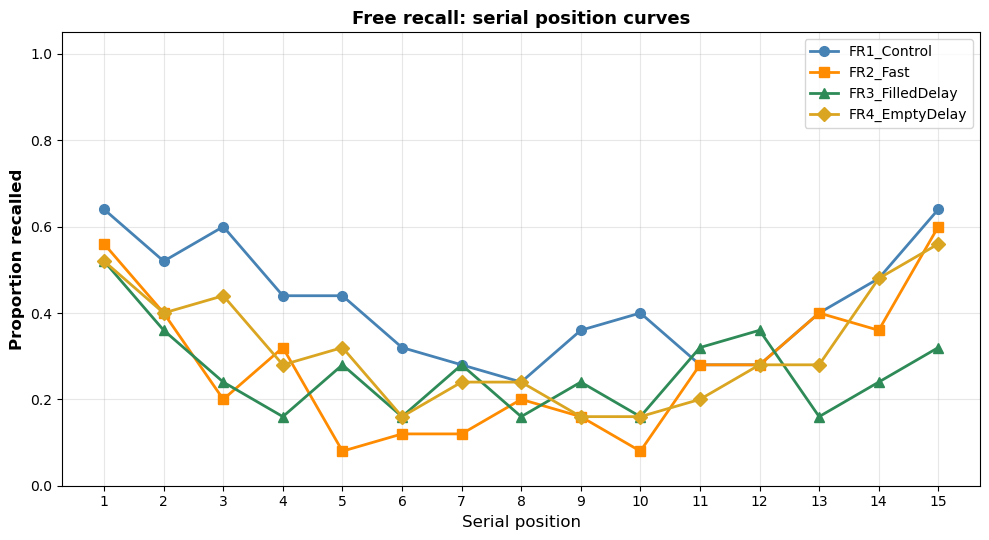

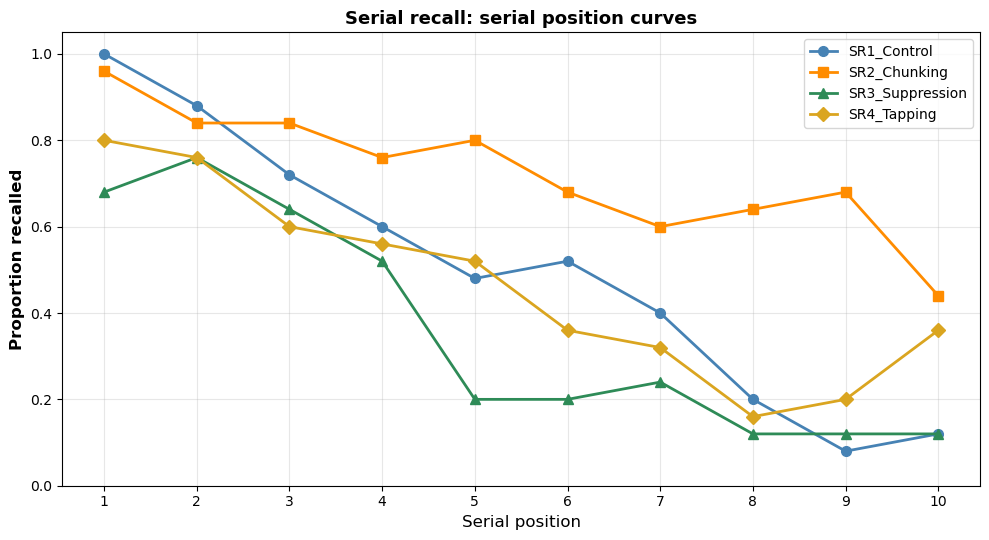

In [12]:
for task in tasks:
    plt.figure(figsize=(10, 5.5))
    i = 0
    for name in position_means[task]:
        y = position_means[task][name]
        x = np.arange(1, len(y) + 1)                 # positions 1, 2, 3, ...
        plt.plot(x, y, color=COLORS[i], marker=MARKERS[i], linewidth=2, markersize=7, label=name)
        i = i + 1
    plt.xticks(x)
    plt.ylim(0, 1.05)
    plt.xlabel("Serial position", fontsize=12)
    plt.ylabel("Proportion recalled", fontsize=12, fontweight="bold")
    plt.title(f"{task}: serial position curves", fontsize=13, fontweight="bold")
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 5. QQ-plot of residuals (ANOVA assumptions)

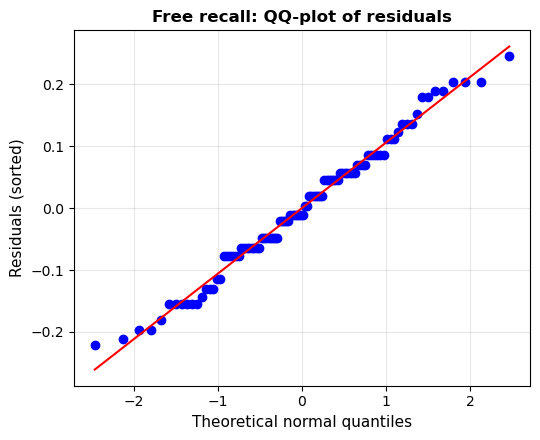

Free recall: SD ratio (largest / smallest) = 1.59
Free recall: Levene's test W = 1.836, p = 0.146



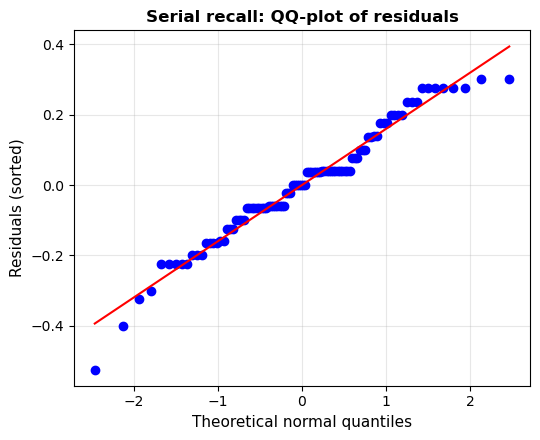

Serial recall: SD ratio (largest / smallest) = 2.98
Serial recall: Levene's test W = 8.194, p = 0.000



In [8]:
for task in tasks:
    # residual = trial score minus the mean of its own condition
    residuals = []
    for name in trial_scores[task]:
        y = trial_scores[task][name]
        for value in y:
            residuals.append(value - np.mean(y))

    plt.figure(figsize=(5.5, 4.5))
    st.probplot(residuals, dist="norm", plot=plt)
    plt.xlabel("Theoretical normal quantiles", fontsize=11)
    plt.ylabel("Residuals (sorted)", fontsize=11)
    plt.title(f"{task}: QQ-plot of residuals", fontsize=12, fontweight="bold")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # equal variance: SD ratio (rule of thumb < 2) and Levene's test
    sds = []
    for name in trial_scores[task]:
        sds.append(np.std(trial_scores[task][name], ddof=1))
    levene = st.levene(*trial_scores[task].values())
    print(f"{task}: SD ratio (largest / smallest) = {max(sds) / min(sds):.2f}")
    print(f"{task}: Levene's test W = {levene.statistic:.3f}, p = {levene.pvalue:.3f}")
    print()

## 6. One-way ANOVA

In [9]:
anova = {}
for task in tasks:
    groups = list(trial_scores[task].values())
    k = len(groups)                                  # number of conditions (4)
    N = 0
    for y in groups:
        N = N + len(y)                               # total number of trials (100)

    all_values = np.concatenate(groups)
    grand_mean = np.mean(all_values)

    SS_tr = 0                                        # variation between the conditions
    SSE = 0                                          # variation within the conditions
    for y in groups:
        SS_tr = SS_tr + len(y) * (np.mean(y) - grand_mean) ** 2
        SSE = SSE + np.sum((y - np.mean(y)) ** 2)

    df_tr = k - 1
    df_e = N - k
    MSE = SSE / df_e
    F = (SS_tr / df_tr) / MSE
    p = st.f.sf(F, df_tr, df_e)                      # P(F-distribution > our F)
    anova[task] = [F, p, MSE, df_e]

    check = st.f_oneway(*groups)                     # same test with scipy
    print("=" * 60)
    print(f"ONE-WAY ANOVA  -  {task.upper()}")
    print("=" * 60)
    print(f"  F({df_tr}, {df_e}) = {F:.3f}")
    print(f"  p-value     = {p:.2e}")
    print(f"  scipy check:  F = {check.statistic:.3f}, p = {check.pvalue:.2e}")
    if p < alpha:
        print(f"  SIGNIFICANT at alpha = {alpha}")
    else:
        print(f"  NOT significant (p >= {alpha})")
    print()

ONE-WAY ANOVA  -  FREE RECALL
  F(3, 96) = 11.214
  p-value     = 2.25e-06
  scipy check:  F = 11.214, p = 2.25e-06
  SIGNIFICANT at alpha = 0.05

ONE-WAY ANOVA  -  SERIAL RECALL
  F(3, 96) = 22.351
  p-value     = 4.64e-11
  scipy check:  F = 22.351, p = 4.64e-11
  SIGNIFICANT at alpha = 0.05



## 7. Bonferroni-corrected pairwise comparisons

In [14]:
for task in tasks:
    F, p_anova, MSE, df_e = anova[task]
    print("=" * 60)
    print(f"BONFERRONI  -  {task.upper()}")
    print("=" * 60)
    if p_anova >= alpha:
        print("  ANOVA not significant -> no pairwise comparisons")
        print()
        continue

    names = list(trial_scores[task].keys())
    M = len(names) * (len(names) - 1) / 2            # number of pairs (6)
    t_crit = st.t.ppf(1 - alpha / (2 * M), df_e)
    print(f"  {int(M)} pairs, each CI at {1 - alpha / M:.2%}")
    print()

    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            y_i = trial_scores[task][names[i]]
            y_j = trial_scores[task][names[j]]
            diff = np.mean(y_i) - np.mean(y_j)
            se = np.sqrt(MSE * (1 / len(y_i) + 1 / len(y_j)))
            low = diff - t_crit * se
            high = diff + t_crit * se
            if low > 0 or high < 0:
                sig = "*"
            else:
                sig = ""
            print(f"  {names[i]:16s} - {names[j]:16s} {diff:+.3f}   [{low:+.3f}, {high:+.3f}] {sig}")
    print()
    print("  * = the CI does not contain 0 (significant difference)")
    print()

BONFERRONI  -  FREE RECALL
  6 pairs, each CI at 99.17%

  FR1_Control      - FR2_Fast         +0.144   [+0.063, +0.225] *
  FR1_Control      - FR3_FilledDelay  +0.157   [+0.076, +0.238] *
  FR1_Control      - FR4_EmptyDelay   +0.107   [+0.026, +0.188] *
  FR2_Fast         - FR3_FilledDelay  +0.013   [-0.068, +0.094] 
  FR2_Fast         - FR4_EmptyDelay   -0.037   [-0.118, +0.044] 
  FR3_FilledDelay  - FR4_EmptyDelay   -0.051   [-0.132, +0.030] 

  * = the CI does not contain 0 (significant difference)

BONFERRONI  -  SERIAL RECALL
  6 pairs, each CI at 99.17%

  SR1_Control      - SR2_Chunking     -0.224   [-0.348, -0.100] *
  SR1_Control      - SR3_Suppression  +0.140   [+0.016, +0.264] *
  SR1_Control      - SR4_Tapping      +0.036   [-0.088, +0.160] 
  SR2_Chunking     - SR3_Suppression  +0.364   [+0.240, +0.488] *
  SR2_Chunking     - SR4_Tapping      +0.260   [+0.136, +0.384] *
  SR3_Suppression  - SR4_Tapping      -0.104   [-0.228, +0.020] 

  * = the CI does not contain 0 (sign

## 8. Accuracy per condition with Bonferroni-corrected CI

FREE RECALL: accuracy with Bonferroni-corrected 98.75% CI
  FR1_Control      158/375   p = 0.421   CI = [0.358, 0.485]
  FR2_Fast         104/375   p = 0.277   CI = [0.220, 0.335]
  FR3_FilledDelay   99/375   p = 0.264   CI = [0.207, 0.321]
  FR4_EmptyDelay   118/375   p = 0.315   CI = [0.255, 0.375]


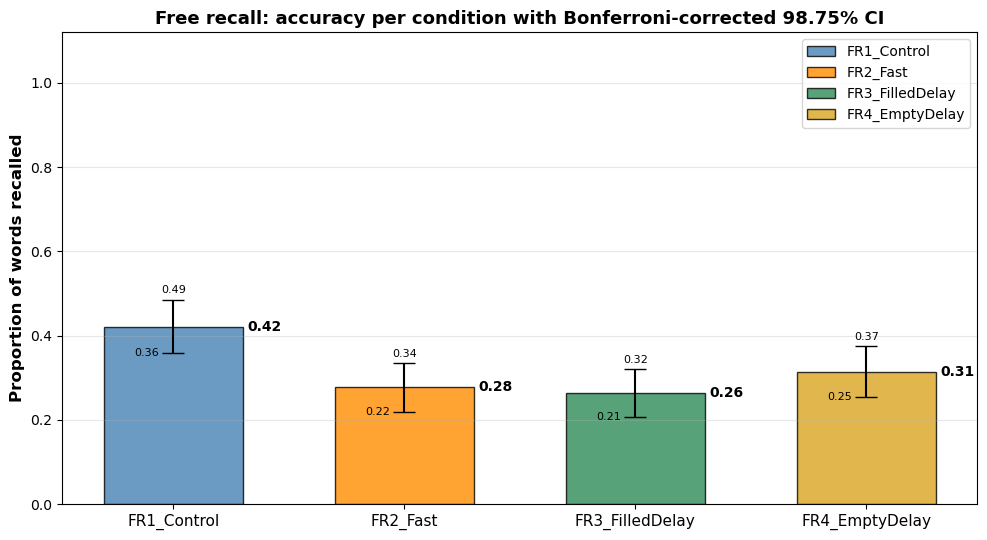


SERIAL RECALL: accuracy with Bonferroni-corrected 98.75% CI
  SR1_Control      125/250   p = 0.500   CI = [0.421, 0.579]
  SR2_Chunking     181/250   p = 0.724   CI = [0.653, 0.795]
  SR3_Suppression   90/250   p = 0.360   CI = [0.284, 0.436]
  SR4_Tapping      116/250   p = 0.464   CI = [0.385, 0.543]


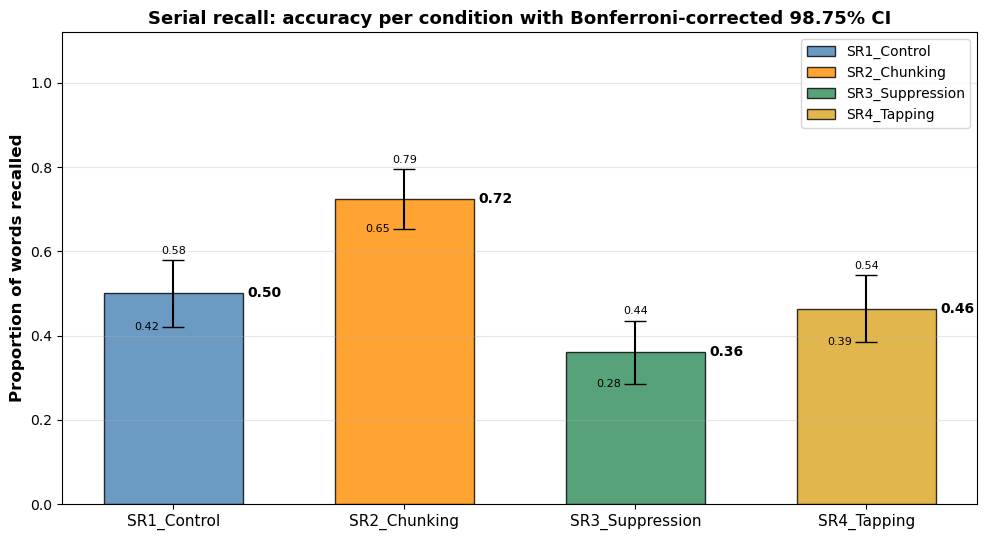

In [ ]:
def proportion_interval(m, n, alpha):
    """CI for a proportion: p +/- z * sqrt(p(1-p)/n)."""
    p = m / n
    z = st.norm.ppf(1 - alpha / 2)
    se = np.sqrt(p * (1 - p) / n)
    return p, p - z * se, p + z * se

for task in tasks:
    names = list(tasks[task].keys())
    M = len(names) * (len(names) - 1) / 2            # number of pairwise comparisons (6)
    alpha_bonf = alpha / M                           # Bonferroni: 0.05 / 6 = 0.0083 per interval
    print("=" * 60)
    print(f"{task.upper()}: accuracy with Bonferroni-corrected {1 - alpha_bonf:.2%} CI (alpha = {alpha} / {int(M)})")
    print("=" * 60)

    plt.figure(figsize=(10, 5.5))
    for i in range(len(names)):
        X = tasks[task][names[i]]
        m = int(np.sum(X))                           # words recalled
        n = X.size                                   # words presented (positions x trials)
        p, low, high = proportion_interval(m, n, alpha_bonf)
        print(f"  {names[i]:16s} {m:3d}/{n}   p = {p:.3f}   CI = [{low:.3f}, {high:.3f}]")

        plt.bar(i, p, width=0.6, color=COLORS[i], alpha=0.8, edgecolor="black", label=names[i])
        plt.errorbar(i, p, yerr=[[p - low], [high - p]], color="black", capsize=8, linewidth=1.5)
        plt.text(i + 0.32, p, f"{p:.2f}", va="center", fontsize=10, fontweight="bold")
        plt.text(i, high + 0.015, f"{high:.2f}", ha="center", fontsize=8)
        plt.text(i - 0.06, low, f"{low:.2f}", ha="right", va="center", fontsize=8)

    plt.xticks(range(len(names)), names, fontsize=11)
    plt.ylim(0, 1.12)
    plt.ylabel("Proportion of words recalled", fontsize=12, fontweight="bold")
    plt.title(f"{task}: accuracy per experiment with Bonferroni-corrected {1 - alpha_bonf:.2%} CI",
              fontsize=13, fontweight="bold")
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()
    print()